## 授權與來源（License & Attribution）

本課程自編與改編內容：Copyright 2026 leonjyentub；授權：Apache License 2.0（`../LICENSE`）。
完整來源及授權資訊：`../SOURCES.md`、`../THIRD_PARTY_NOTICES.md`。

參考與改編來源：Aurélien Géron, `ageron/handson-mlp`（Apache-2.0），固定版本 `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`；`leonjyentub/MachineLearning2025` 為課程作者自有專案。
本教學檔案的變更與取捨：參考 handson-mlp Ch.4；另整合 MachineLearning2025 的 GD 與迴歸示範。 將原範例重新編排，配合課堂增補解說、資料流程或縮小實驗；原作者不為本課程背書。

本授權只適用於本 Notebook 中權利人有權授權的程式與文字；第三方資料、圖片與其他權利依各原始條款。

# 04｜線性模型與最佳化

對應 `slides/04_線性模型與最佳化.md`。本檔由 `09_線性模型與最佳化.ipynb` 改名，程式與已執行輸出保留。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 三種最小平方解法：正規方程、lstsq 與 SVD 偽反矩陣

教材資料生成規則 $y = 4 + 3x + \varepsilon$。三種解法在滿欄秩時給相同係數；程式一般用 `lstsq`／SVD，不自行反矩陣。

In [2]:
rng = np.random.default_rng(SEED)
x = rng.uniform(0, 2, size=(120, 1))
y = 4 + 3 * x[:, 0] + rng.normal(0, 1, size=120)
Xb = np.c_[np.ones(len(x)), x]                      # 第一欄為截距

theta_normal = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y # 正規方程：需要 X^T X 可逆
theta_lstsq = np.linalg.lstsq(Xb, y, rcond=None)[0] # 最小平方求解器
theta_pinv = np.linalg.pinv(Xb) @ y                # SVD 偽反矩陣 X^+ y

from sklearn.linear_model import LinearRegression
sk = LinearRegression().fit(x, y)
assert np.allclose(theta_normal, theta_lstsq) and np.allclose(theta_lstsq, theta_pinv)
assert np.allclose(theta_lstsq, [sk.intercept_, sk.coef_[0]])
pd.DataFrame({'normal_equation': theta_normal, 'lstsq': theta_lstsq, 'pinv_SVD': theta_pinv},
             index=['intercept', 'slope'])

,normal_equation,lstsq,pinv_SVD
intercept,3.998009,3.998009,3.998009
slope,2.992976,2.992976,2.992976


In [3]:
# 共線：加入 x2 = 2*x1，X^T X 變成奇異，正規方程失效；lstsq / pinv 仍給「最小範數」解。
Xc = np.c_[np.ones(len(x)), x[:, 0], 2 * x[:, 0]]
singular = False
try:
    np.linalg.inv(Xc.T @ Xc)
except np.linalg.LinAlgError:
    singular = True
theta_c = np.linalg.lstsq(Xc, y, rcond=None)[0]
assert singular
assert np.isclose(theta_c[1] + 2 * theta_c[2], theta_lstsq[1], atol=1e-6)  # 只有 θ1 + 2θ2 被決定
print('inv(X^T X) 失敗（奇異）:', singular)
print('min-norm 解:', np.round(theta_c, 4), ' θ1 + 2·θ2 =', round(theta_c[1] + 2 * theta_c[2], 4))

inv(X^T X) 失敗（奇異）: True
min-norm 解: [3.998  0.5986 1.1972]  θ1 + 2·θ2 = 2.993


## 2. 手算驗算：三個點決定哪一條線？

對應投影片活動「三個點能決定哪一條線？」。資料 $(0,1),(1,3),(2,5)$，含截距的 $X$ 三列為 $[1,0],[1,1],[1,2]$。

In [4]:
X3 = np.array([[1., 0.], [1., 1.], [1., 2.]])
y3 = np.array([1., 3., 5.])
def mse(theta, X, y):
    return float(np.mean((X @ theta - y) ** 2))
row = {'theta=(1,2)': mse(np.array([1., 2.]), X3, y3),
       'theta=(0,2)': mse(np.array([0., 2.]), X3, y3)}
assert row['theta=(1,2)'] == 0.0 and row['theta=(0,2)'] == 1.0
pd.Series(row, name='MSE')

theta=(1,2)    0.0
theta=(0,2)    1.0
Name: MSE, dtype: float64

## 3. 批次梯度下降：學習率決定收斂、偏慢或發散

在標準化座標下，MSE 梯度為 $\nabla_\theta J = \frac{2}{m}X^\top(X\theta-y)$。三個學習率對照教材圖 4-8。

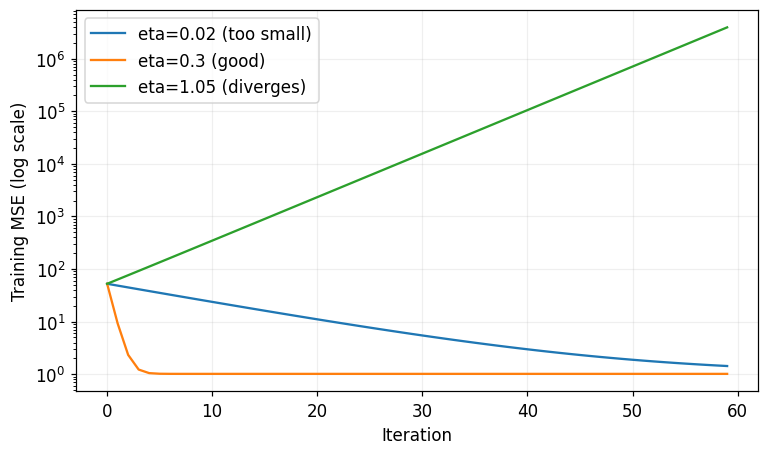

,eta,note,final_logged_MSE
0,0.02,too small,1.431584e+00
1,0.30,good,1.015470e+00
2,1.05,diverges,3.940430e+06


In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(x)
Z = np.c_[np.ones(len(x)), scaler.transform(x)]

def batch_gd(Z, y, eta, epochs=60):
    theta = np.zeros(Z.shape[1]); hist = []
    for _ in range(epochs):
        err = Z @ theta - y
        hist.append(np.mean(err ** 2))
        theta = theta - eta * (2 / len(Z)) * Z.T @ err
    return theta, np.array(hist)

rows = []
for eta, label in [(0.02, 'too small'), (0.3, 'good'), (1.05, 'diverges')]:
    theta, hist = batch_gd(Z, y, eta)
    rows.append({'eta': eta, 'note': label, 'final_logged_MSE': hist[-1]})
    plt.semilogy(np.clip(hist, 1e-3, 1e12), label=f'eta={eta} ({label})')
plt.xlabel('Iteration'); plt.ylabel('Training MSE (log scale)'); plt.legend()
savefig('09_gradient_learning_rate')

theta_good, _ = batch_gd(Z, y, 0.3, epochs=400)
theta_closed = np.linalg.lstsq(Z, y, rcond=None)[0]
assert np.allclose(theta_good, theta_closed, atol=1e-4)
assert rows[2]['final_logged_MSE'] > rows[0]['final_logged_MSE']       # eta=1.05 發散
pd.DataFrame(rows)

## 4. 手算驗算：一次更新後損失是否下降？

對應投影片活動「手算一次更新」。$X=\begin{bmatrix}1&0\\1&1\end{bmatrix}$、$y=(1,3)^\top$、$\theta=(0,0)^\top$、$\eta=0.1$。

In [6]:
Xa = np.array([[1., 0.], [1., 1.]]); ya = np.array([1., 3.]); theta = np.zeros(2)
resid = Xa @ theta - ya                       # [-1, -3]
grad = (2 / len(Xa)) * Xa.T @ resid           # [-4, -3]
theta_new = theta - 0.1 * grad                # [0.4, 0.3]
assert np.allclose(resid, [-1, -3]) and np.allclose(grad, [-4, -3])
assert np.allclose(theta_new, [0.4, 0.3])
assert np.isclose(mse(theta, Xa, ya), 5.0) and np.isclose(mse(theta_new, Xa, ya), 2.825)
pd.Series({'residual': resid.tolist(), 'gradient': grad.tolist(), 'theta_new': theta_new.tolist(),
           'MSE_before': mse(theta, Xa, ya), 'MSE_after': mse(theta_new, Xa, ya)})

residual                    [-1.0, -3.0]
gradient                    [-4.0, -3.0]
theta_new     [0.4, 0.30000000000000004]
MSE_before                           5.0
MSE_after                          2.825
dtype: object

## 5. SGD、mini-batch 與學習率排程

`SGDRegressor` 逐筆更新、每個 epoch 打亂資料；學習率可用排程 $\eta_t = t_0/(t+t_1)$ 逐步縮小。下圖比較三種方法在參數空間的更新路徑（教材圖 4-11）。

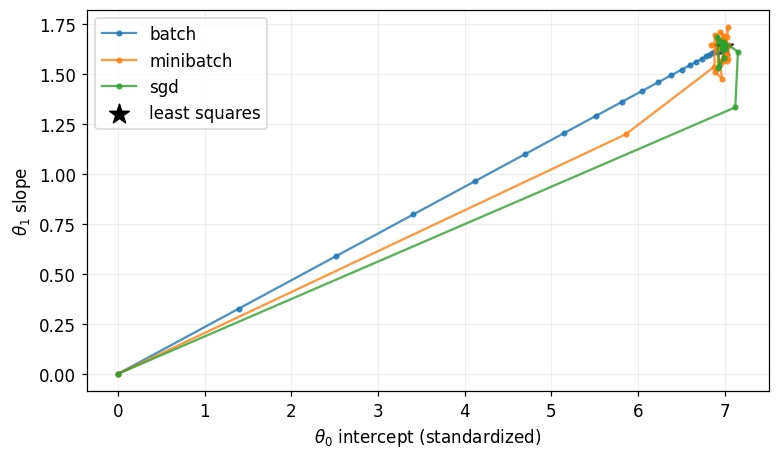

SGDRegressor coef vs least squares (standardized): [1.629] [1.632]


In [7]:
from sklearn.linear_model import SGDRegressor
target = y

def run_path(kind, epochs=25, batch=1, eta=0.1):
    theta = np.zeros(Z.shape[1]); path = [theta.copy()]
    idx = np.arange(len(Z)); step = 0
    for _ in range(epochs):
        np.random.default_rng(SEED + _).shuffle(idx)
        if kind == 'batch':
            g = (2 / len(Z)) * Z.T @ (Z @ theta - target)
            theta = theta - eta * g; path.append(theta.copy()); continue
        for s in range(0, len(Z), batch):
            step += 1
            b = idx[s:s + batch]
            g = (2 / len(b)) * Z[b].T @ (Z[b] @ theta - target[b])
            lr = eta if kind == 'minibatch' else 5.0 / (step + 50)   # SGD 用排程
            theta = theta - lr * g
        path.append(theta.copy())
    return np.array(path)

for kind, kw in [('batch', {}), ('minibatch', {'batch': 16}), ('sgd', {'batch': 1})]:
    p = run_path(kind, **kw)
    plt.plot(p[:, 0], p[:, 1], marker='.', alpha=.8, label=kind)
plt.scatter(theta_closed[0], theta_closed[1], marker='*', s=180, c='k', label='least squares')
plt.xlabel(r'$\theta_0$ intercept (standardized)'); plt.ylabel(r'$\theta_1$ slope'); plt.legend()
savefig('09_gd_paths')

sgd = SGDRegressor(penalty=None, max_iter=1000, tol=1e-4, random_state=SEED).fit(Z[:, 1:], y)
print('SGDRegressor coef vs least squares (standardized):',
      np.round(sgd.coef_, 3), np.round(theta_closed[1:], 3))

## 6. 多項式迴歸與學習曲線

多項式先轉換特徵再套線性模型，對參數仍是線性。學習曲線把訓練與驗證誤差畫成資料量的函數，用來分辨欠擬合（兩線都高且接近）與過擬合（兩線有明顯落差）。

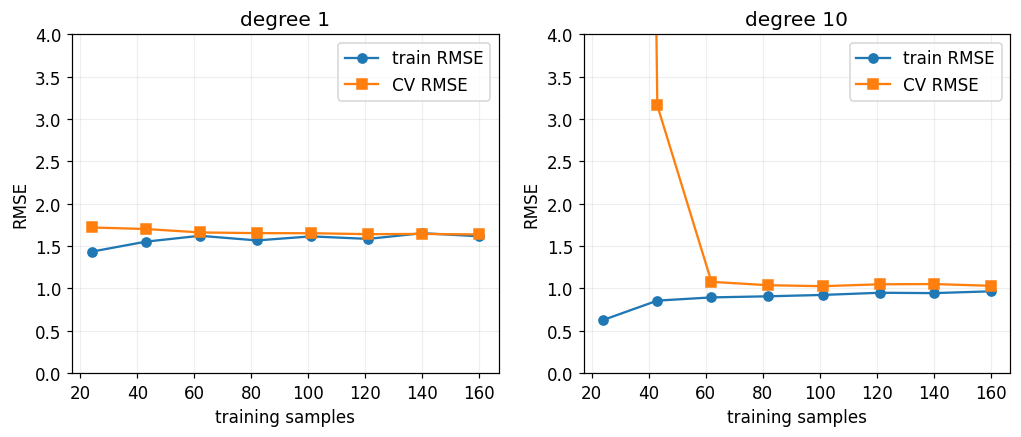

,train_RMSE_full,CV_RMSE_full
1,1.616353,1.638491
2,0.997156,0.999577
10,0.966553,1.031945


In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import learning_curve
from sklearn.metrics import root_mean_squared_error

rng = np.random.default_rng(SEED)
xc = rng.uniform(-3, 3, size=(200, 1))
yc = 0.5 * xc[:, 0] ** 2 + xc[:, 0] + 2 + rng.normal(0, 1, 200)   # 彎曲資料

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sizes = np.linspace(0.15, 1.0, 8)
for degree, ax in [(1, axes[0]), (10, axes[1])]:
    model = make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), LinearRegression())
    ts, tr, va = learning_curve(model, xc, yc, train_sizes=sizes, cv=5,
                                scoring='neg_root_mean_squared_error')
    ax.plot(ts, -tr.mean(1), 'o-', label='train RMSE')
    ax.plot(ts, -va.mean(1), 's-', label='CV RMSE')
    ax.set(title=f'degree {degree}', xlabel='training samples', ylabel='RMSE', ylim=(0, 4)); ax.legend()
savefig('09_learning_curves')

gap = {}
for degree in [1, 2, 10]:
    m = make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), LinearRegression()).fit(xc, yc)
    ts, tr, va = learning_curve(m, xc, yc, train_sizes=sizes, cv=5, scoring='neg_root_mean_squared_error')
    gap[degree] = {'train_RMSE_full': float(-tr.mean(1)[-1]), 'CV_RMSE_full': float(-va.mean(1)[-1])}
assert gap[1]['train_RMSE_full'] > gap[2]['train_RMSE_full']            # degree 1 欠擬合
assert gap[10]['CV_RMSE_full'] - gap[10]['train_RMSE_full'] > gap[2]['CV_RMSE_full'] - gap[2]['train_RMSE_full']
report('linear_optimization', {'least_squares_theta': theta_closed.tolist(),
       'gd_learning_rates': rows, 'learning_curve_gap': gap})
pd.DataFrame(gap).T

## 練習與參考答案

- 共線時為什麼不能直接反轉 $X^\top X$？**矩陣奇異（欄不獨立），反矩陣不存在；`lstsq`／SVD 給出最小範數解，但個別係數仍不可辨識。**
- 學習率調小能讓直線變成拋物線嗎？**不能，那是模型表達能力問題；要改特徵或模型。**
- 圖 4-15 型（訓練＝驗證且都高）該怎麼辦？**先查欠擬合：換更合適的特徵或模型，不是只蒐集更多資料。**
- 偏差–變異數的數據化拆解見 Notebook 02 第 5 節；本檔聚焦最佳化與學習曲線。